In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("case3_retail_kmeans_1000.csv")
df.head()

,NumPurchases,AvgBillAmount,MonthlyVisits,TotalSpending
0,44,2470,14,166713
1,58,3416,9,106754
2,41,3665,10,140194
3,51,3468,13,104544
4,56,2808,12,140180


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   NumPurchases   999 non-null    int64
 1   AvgBillAmount  999 non-null    int64
 2   MonthlyVisits  999 non-null    int64
 3   TotalSpending  999 non-null    int64
dtypes: int64(4)
memory usage: 31.3 KB


In [4]:
df.columns

Index(['NumPurchases', 'AvgBillAmount', 'MonthlyVisits', 'TotalSpending'], dtype='object')

In [7]:
X = df[['NumPurchases', 'AvgBillAmount', 'MonthlyVisits', 'TotalSpending']]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

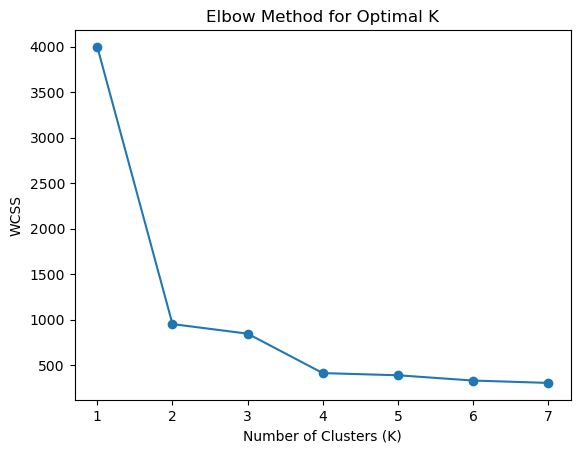

In [9]:
wcss = []

for k in range (1,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,8), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df

,NumPurchases,AvgBillAmount,MonthlyVisits,TotalSpending,Cluster
0,44,2470,14,166713,1
1,58,3416,9,106754,1
2,41,3665,10,140194,1
3,51,3468,13,104544,1
4,56,2808,12,140180,1
...,...,...,...,...,...
994,9,589,0,9007,0
995,3,633,0,17611,0
996,7,221,0,3328,0
997,3,799,0,10019,0


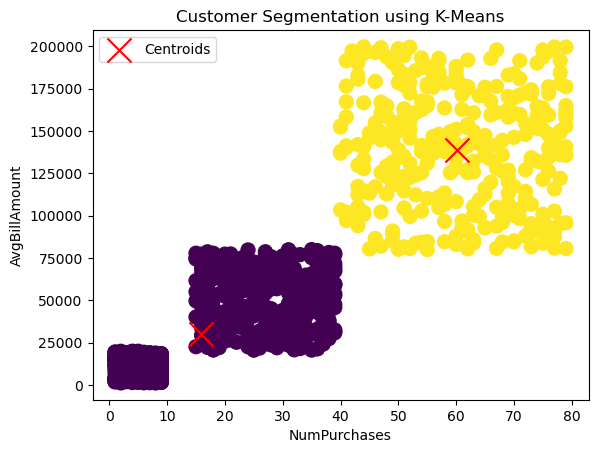

In [18]:
#Visualize the cluster
plt.figure()

plt.scatter(
    df['NumPurchases'], df['TotalSpending'], c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel("NumPurchases")
plt.ylabel("AvgBillAmount")
plt.title("Customer Segmentation using K-Means")

#Now plotting centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0], centroids[:,3], s=300, c='red', marker='x', label='Centroids')
plt.legend()
plt.show()